### Setup

In [1]:
# standard imports
import numpy as np
from torchvision import transforms, datasets
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [3]:
# load in train / test data
train_data = datasets.MNIST(
    root="../.",
    train=True,
    transform=transforms.ToTensor()
)

test_data = datasets.MNIST(
    root="../.",
    train=False,
    transform=transforms.ToTensor()
)

In [ ]:
# write out full data to be imported to sheets
np.savetxt('data.csv', train_data.data[:5000].flatten(1).numpy()/255, delimiter=',')
np.savetxt('targets.csv', train_data.targets[:5000].numpy(), delimiter=',')

### Training

In [70]:
# performs a forward pass given parameters and input data
def model(b1, W1, b2, W2, X):
    hL = np.maximum(0, X @ W1 + b1) # (n, d) @ (d, h): (n, h)
    logits = hL @ W2 + b2 # (n, h) @ (h, k): (n, k)
    return logits

In [84]:
np.random.seed(52)
# set sizes / data
train_size = 4000
batch_size = 500
val_size = 500
test_size = 500
X = train_data.data[:train_size].numpy()/255 # standard division by 255 to make values range from [0,1]
y = train_data.targets[:train_size].numpy()
X_val = train_data.data[train_size:train_size+val_size].numpy()/255 # use next val_size as validation set 
y_val = train_data.targets[train_size:train_size+val_size].numpy()
X_test = train_data.data[train_size+val_size:train_size+val_size+test_size].numpy()/255 # use next test_size as test set 
y_test = train_data.targets[train_size+val_size:train_size+val_size+test_size].numpy()

k = 10 # number of classes
d = 784 # dimensionality of the input
h = 128 # size of hidden layer
step_size = 0.1 # proportional to learning rate

# specific initialization (same as sheets)
w = np.genfromtxt('weights.csv')
b1 = w[128*784:128*784+128] # layer 1 biases
b2 = w[-10:] # layer 2 biases 
W1 = w[:128*784].reshape(h,d).T # layer 1 weights
W2 = w[128*784+128:-10].reshape(k,h).T # layer 2 weights

epochs = 7
for t in range(epochs):
    for i in range(int(np.ceil(train_size/batch_size))):
        # forward pass
        # set batch indices / data
        batch_index_l = batch_size*i
        batch_index_h = batch_size*(i+1)
        X_batch = X[batch_index_l:batch_index_h]
        y_batch = y[batch_index_l:batch_index_h]
        n = len(X_batch) # number of points in batch (may differ from batch size)
        X_batch = X_batch.reshape(n, -1) # (n, 1, 28, 28) => (n, 784)
        hL = np.maximum(0, X_batch @ W1 + b1) # (n, d) @ (d, h): (n, h)
        logits = hL @ W2 + b2 # (n, h) @ (h, k): (n, k)

        # compute probabilities
        probs = np.exp(logits) # (n, k)
        probs /= probs.sum(1, keepdims=True) # (n, k)

        # compute average cross-entropy loss
        neg_log_probs = -np.log(probs[range(n),y_batch]) # (n,)
        loss = neg_log_probs.sum() / n # (1)
        
        # compute the gradient on logits
        dlogits = probs # (n, k)
        dlogits[range(n),y_batch] -= 1 # (n, k)

        # compute gradients on layer 2 W/b 
        db2 = dlogits.sum(0) # (n, k) => (k)
        dW2 = hL.T @ dlogits # (n, h).T @ (n, k): (h, k) 

        # compute gradients on layer 1 W/b
        dhL = dlogits @ W2.T # (n, k) @ (h, k).T: (n, h) 
        dhL[hL <= 0] = 0 # (n, h)
        dW1 = X_batch.T @ dhL # (n, d).T @ (n, h): (d, h)
        db1 = dhL.sum(0) # (n, h) => (h)

        # parameter updates
        W1  -= step_size * dW1 / n # (d, h)
        b1  -= step_size * db1 / n # (h)
        W2 -= step_size * dW2 / n # (h, k)
        b2 -= step_size * db2 / n # (k)
        
        # evaluation metrics
        train_preds = model(b1, W1, b2, W2, X_batch.reshape(n, 784)).argmax(1)
        train_acc = (train_preds == y_batch).sum() / n
        val_preds = model(b1, W1, b2, W2, X_val.reshape(len(X_val), 784)).argmax(1)
        val_acc = (val_preds == y_val).sum() / len(y_val)
        print('Epoch:', t+1, 'Batch:', i+1,'Train Accuracy:', train_acc, 'Train Loss:', round(loss,3), 'Val Accuracy:', val_acc)

Epoch: 1 Batch: 1 Train Accuracy: 0.048 Train Loss: 2.308 Val Accuracy: 0.054
Epoch: 1 Batch: 2 Train Accuracy: 0.1 Train Loss: 2.301 Val Accuracy: 0.08
Epoch: 1 Batch: 3 Train Accuracy: 0.12 Train Loss: 2.297 Val Accuracy: 0.108
Epoch: 1 Batch: 4 Train Accuracy: 0.154 Train Loss: 2.291 Val Accuracy: 0.164
Epoch: 1 Batch: 5 Train Accuracy: 0.27 Train Loss: 2.287 Val Accuracy: 0.202
Epoch: 1 Batch: 6 Train Accuracy: 0.268 Train Loss: 2.285 Val Accuracy: 0.254
Epoch: 1 Batch: 7 Train Accuracy: 0.294 Train Loss: 2.28 Val Accuracy: 0.276
Epoch: 1 Batch: 8 Train Accuracy: 0.356 Train Loss: 2.272 Val Accuracy: 0.314
Epoch: 2 Batch: 1 Train Accuracy: 0.394 Train Loss: 2.271 Val Accuracy: 0.346
Epoch: 2 Batch: 2 Train Accuracy: 0.442 Train Loss: 2.268 Val Accuracy: 0.398
Epoch: 2 Batch: 3 Train Accuracy: 0.428 Train Loss: 2.261 Val Accuracy: 0.444
Epoch: 2 Batch: 4 Train Accuracy: 0.512 Train Loss: 2.25 Val Accuracy: 0.478
Epoch: 2 Batch: 5 Train Accuracy: 0.546 Train Loss: 2.244 Val Accuracy:

### Evaluation

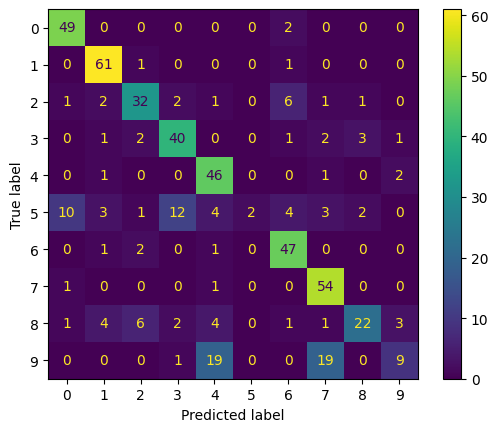

In [ ]:
cm = confusion_matrix(y_test, model(b1, W1, b2, W2, X_test.reshape(len(X_test), 784)).argmax(1))
ConfusionMatrixDisplay(cm).plot();